In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import warnings 

import warnings
warnings.filterwarnings('ignore')

In [3]:
train = np.loadtxt('machine-1-1.txt', delimiter=',')

# Load test data
test = np.loadtxt("machine-1-1.txt", delimiter=',')

# Load labels (0 = normal, 1 = anomaly)
labels = np.loadtxt("machine-1-1.txt", delimiter=',')

In [5]:
train_df = pd.DataFrame(train)
test_df = pd.DataFrame(test)

print(train_df.shape)
print(test_df.shape)

(28479, 38)
(28479, 38)


In [6]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
0,0.032258,0.039195,0.027871,0.024390,0.0,0.915385,0.343691,0.0,0.020011,0.000122,...,0.0,0.004298,0.029993,0.022131,0.0,0.000045,0.034677,0.034747,0.0,0.0
1,0.043011,0.048729,0.033445,0.025552,0.0,0.915385,0.344633,0.0,0.019160,0.001722,...,0.0,0.004298,0.030041,0.028821,0.0,0.000045,0.035763,0.035833,0.0,0.0
2,0.043011,0.034958,0.032330,0.025552,0.0,0.915385,0.344633,0.0,0.020011,0.000122,...,0.0,0.004298,0.026248,0.021101,0.0,0.000045,0.033012,0.033082,0.0,0.0
3,0.032258,0.028602,0.030100,0.024390,0.0,0.912821,0.342750,0.0,0.021289,0.000000,...,0.0,0.004298,0.030169,0.025733,0.0,0.000022,0.035112,0.035182,0.0,0.0
4,0.032258,0.019068,0.026756,0.023229,0.0,0.912821,0.342750,0.0,0.018734,0.000000,...,0.0,0.004298,0.027240,0.022645,0.0,0.000034,0.033447,0.033517,0.0,0.0


In [7]:
train_df.shape

(28479, 38)

In [8]:
train_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
count,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,...,28479.0,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.0
mean,0.064195,0.056882,0.053549,0.050188,0.0,0.913552,0.262274,0.0,0.020346,0.000159,...,0.0,0.005501,0.047294,0.036172,0.000188,0.000033,0.050351,0.050401,0.0,0.0
std,0.056685,0.042516,0.037695,0.037443,0.0,0.037972,0.066661,0.0,0.009982,0.001287,...,0.0,0.002545,0.033065,0.023716,0.000201,0.000015,0.035048,0.035044,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.006146,0.006691,0.000000,0.000000,0.008760,0.008759,0.0,0.0
25%,0.032258,0.027542,0.027871,0.024390,0.0,0.907692,0.251412,0.0,0.012347,0.000000,...,0.0,0.004298,0.026128,0.021101,0.000000,0.000022,0.027945,0.028015,0.0,0.0
50%,0.043011,0.045551,0.042363,0.037166,0.0,0.912821,0.274011,0.0,0.021005,0.000000,...,0.0,0.004298,0.034858,0.027792,0.000000,0.000034,0.036415,0.036485,0.0,0.0
75%,0.086022,0.075212,0.070234,0.067364,0.0,0.920513,0.311676,0.0,0.027959,0.000122,...,0.0,0.007163,0.062250,0.044261,0.000386,0.000045,0.066025,0.066020,0.0,0.0
max,0.494624,0.421610,0.278707,0.250871,0.0,1.000000,0.360640,0.0,0.118081,0.140435,...,0.0,0.028653,0.275407,0.303139,0.002318,0.001271,0.311229,0.311206,0.0,0.0


In [9]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

In [10]:
mean = train_df.mean()
std = train_df.std()

z_scores = (test_df - mean) / std

# Threshold (3 is common)
threshold = 3

# If ANY feature crosses threshold → anomaly
z_preds = (np.abs(z_scores) > threshold).any(axis=1).astype(int)

Plot Z-score anomalies

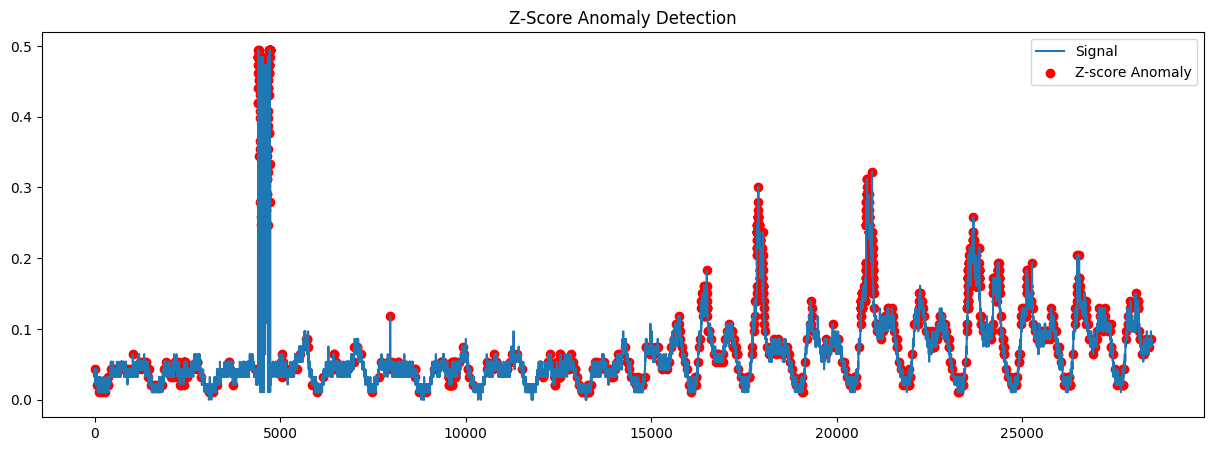

In [12]:
plt.figure(figsize=(15,5))

plt.plot(test_df[0], label="Signal")

z_anomaly_idx = np.where(z_preds == 1)[0]

plt.scatter(z_anomaly_idx,
            test_df[0].iloc[z_anomaly_idx],
            color='red',
            label='Z-score Anomaly')

plt.title("Z-Score Anomaly Detection")
plt.legend()
plt.show()

Train Isolation Forest

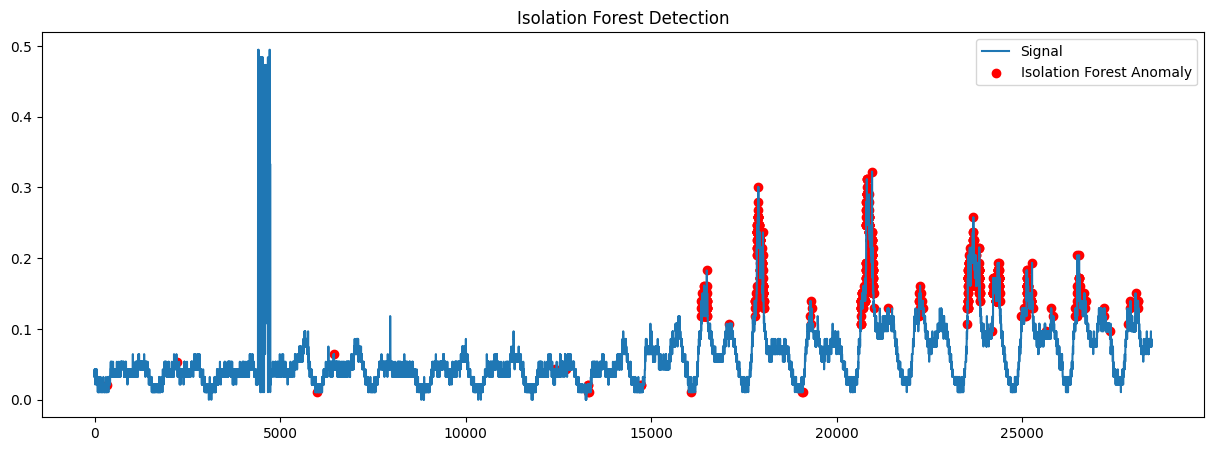

In [14]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_model.fit(train_df)

iso_preds = iso_model.predict(test_df)
iso_preds = np.where(iso_preds == -1, 1, 0)

# Plot
plt.figure(figsize=(15,5))

plt.plot(test_df[0], label="Signal")

iso_anomaly_idx = np.where(iso_preds == 1)[0]

plt.scatter(iso_anomaly_idx,
            test_df[0].iloc[iso_anomaly_idx],
            color='red',
            label='Isolation Forest Anomaly')

plt.title("Isolation Forest Detection")
plt.legend()
plt.show()

LSTM Autoencoder